# Pyomo.DoE: Optimization

Our [earlier exploratory analysis](./doe_exploratory_analysis.ipynb) showed the sine wave experiment alone is rank deficient. What if instead of optimizing the sine wave parameters $a$ and $p$, we directly optimize $u(t)$. In other words, we will formulate model-based design of experiments as an [optimal control problem](./pyomo_simulation.ipynb).

Maximize a scalar-valued function $\psi(\cdot)$ of the Fisher information matrix $\mathbf{M}$:

$$
\begin{align*}
\max_{u} \quad & \psi(\mathbf{M}(u) + \mathbf{M}_0) \\
\mathrm{s.t.} \quad & C_p^H \frac{dT_H}{dt} = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t)\\
& C_p^S \frac{dT_S}{dt} = U_b (T_H - T_S)  \\
& 0\% \leq u(t) \leq 100 \% \\
& T_H(t_0) = T_{amb} \\
& T_S(t_0) = T_{amb}
\end{align*}
$$

`Pyomo.DoE` automatically formulates, initializes, and solves this optimization problem for $\psi(\cdot) =\mathrm{trace}(\cdot)$, i.e., A-optimality, and $\psi(\cdot) = \log_{10}(\mathrm{det}(\cdot))$, i.e., D-optimality.

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)

We will load the sine test data to serve as an initial point. Recall our create model function will use supplied data to initialize the Pyomo model. Carefully initialization is often required for optimization of large-scale dynamic systems.

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


We will store the data in an instance of our `TC_Lab_data` dataclass.

In [3]:
# Here, we will induce a step size of 6 seconds, as to not give too many 
# degrees of freedom for experimental design.
skip =6

# Create the data object considering the new control points every 6 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

## Calculate FIM at initial point (sine test)

We will start computing the FIM of the sine test experiment.

In [4]:
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments

from pyomo.environ import SolverFactory

# Copied from previous notebook
theta_values = {
    'Ua': 0.041007,
    'Ub': 0.014152,
    'inv_CpH': 0.170600,
    'inv_CpS': 4.545456,
}

We will re-define the prior FIM from the ParmEst exercise from the $L_2$ regularization


In [5]:


import numpy as np



cov = np.array([
    [2.431122e-10, -1.411022e-09, 4.013878e-09, -2.421788e-11],
    [-1.411022e-09, 1.159466e-06, 5.106751e-07, -3.727706e-04],
    [4.013878e-09, 5.106751e-07, 4.906845e-07, -1.975614e-04],
    [-2.421788e-11, -3.727706e-04, -1.975614e-04, 1.249945e-01],
])

FIM_raw = np.linalg.inv(cov)

theta_nom = np.array([
    theta_values['Ua'],
    theta_values['Ub'],
    theta_values['inv_CpH'],
    theta_values['inv_CpS'],
])

FIM_raw = np.linalg.inv(cov)
scale_constant_value=1e-3
D = np.diag(theta_nom)
FIM = scale_constant_value**2 * FIM_raw
# * (D @ FIM_raw @ D)




## Sensitivity Computation for the Design of Experiments

Recall that Pyomo.DoE utilizes the sensitivity matrix defined as the derivative of the estimates of the measured outputs $\hat{y}$ with respect to the parameter to be estimated $\hat{\theta}$:
$$
Q = \nabla_{\hat{\theta}} \hat{y}
$$
to compute the FIM as:
$$
M = Q^T \Sigma^{-1}Q 
$$
where $\Sigma$ is the measurement covariance matrix

Pyomo.DoE offers two different approaches to computing the sensitivity matrix:
1. Finite difference method: With Central finite difference method that utilizes parameter perturbations for estimating the sensitivity matrix as: $$Q \approx \frac{\hat{y}(\hat{\theta} + \Delta \hat{\theta})- \hat{y}(\hat{\theta} - \Delta \hat{\theta})}{2 \Delta \hat{\theta}}$$ where $\Delta \hat{\theta}$ is the step size
2. Automatic differentiation method: Pyomo.DoE uses automatic differentiation in PyNumero to compute sensitivities directly from the model equations, avoiding repeated parameter perturbation solves: $$\nabla_{\hat{\theta}}F = \begin{bmatrix}\nabla_{\hat{y}}F\\\nabla_{\hat{x}}F\end{bmatrix}\begin{bmatrix}\nabla_{\hat{\theta}}\hat{y}\\\nabla_{\hat{\theta}}\hat{x}\end{bmatrix}$$ where $F(\hat{x},\hat{y}, \hat{\theta}, u) = 0$ is the model of the system

We can demonstrate the improvement in the solver performance and time metrics using both automatic differentiation  and the central finite difference methods for sensitivity computation

## Run D-optimality experiment using automatic Differentiation

In [6]:

# Create experiment object for design of experiments
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states)

# Create the design of experiments object using our experiment instance from above and compute gradients as usual
TC_Lab_DoE_D = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=scale_constant_value,
                                 scale_nominal_param_value=True,
                                 objective_option="determinant",  # Now we specify a type of objective, D-opt = "determinant"
                                 prior_FIM=FIM,  # We use the prior information from the existing experiment!,,,,,,,,,,,,,,,,,,,,,,,
                                 tee=False,)


TC_Lab_DoE_D.run_doe()


We now re-run the experiment but use the automatic differentiation-based gradient computation

In [7]:

TC_Lab_DoE_D_AD = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=scale_constant_value,
                                 scale_nominal_param_value=True,
                                 gradient_method = "pynumero", # We choose gradients generated by the automatic differentiation
                                 objective_option="determinant",  
                                 prior_FIM=FIM, 
                                 tee=False,)


TC_Lab_DoE_D_AD.run_doe()

Lets compare the time performance

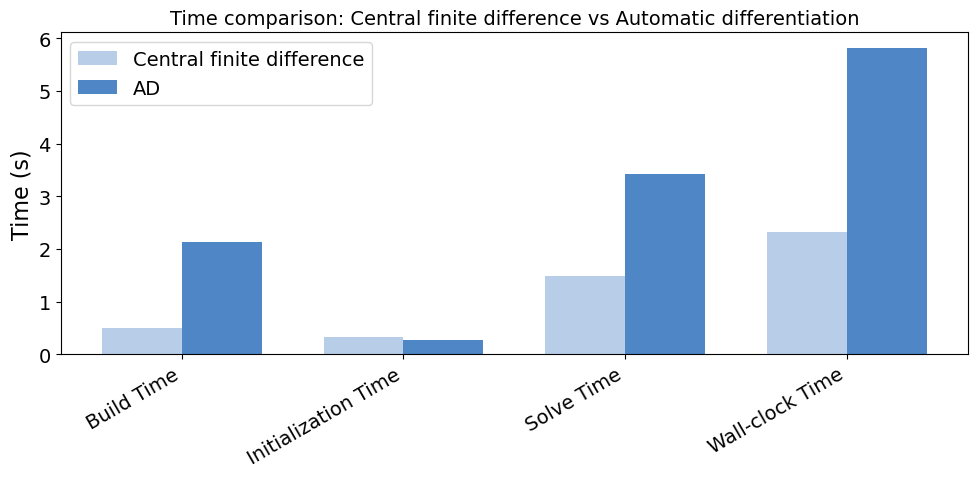

In [8]:
import matplotlib.pyplot as plt
import numpy as np

central_time_metrics = {
    "Build Time": TC_Lab_DoE_D.results.get("Build Time"),
    "Initialization Time": TC_Lab_DoE_D.results.get("Initialization Time"),
    "Solve Time": TC_Lab_DoE_D.results.get("Solve Time"),
    "Wall-clock Time": TC_Lab_DoE_D.results.get("Wall-clock Time"),
}

AD_time_metrics = {
    "Build Time": TC_Lab_DoE_D_AD.results.get("Build Time"),
    "Initialization Time": TC_Lab_DoE_D_AD.results.get("Initialization Time"),
    "Solve Time": TC_Lab_DoE_D_AD.results.get("Solve Time"),
    "Wall-clock Time": TC_Lab_DoE_D_AD.results.get("Wall-clock Time"),
}

labels = []
central_vals = []
AD_vals = []

for key in central_time_metrics:
    c = central_time_metrics.get(key)
    s = AD_time_metrics.get(key)
    if c is None or s is None:
        continue
    try:
        c = float(c)
        s = float(s)
    except (TypeError, ValueError):
        continue
    labels.append(key)
    central_vals.append(c)
    AD_vals.append(s)

x = np.arange(len(labels))
width = 0.36

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, central_vals, width, label="Central finite difference", color="#b7cde8")
plt.bar(x + width/2, AD_vals, width, label="AD", color="#4f86c6")

plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("Time (s)")
plt.title("Time comparison: Central finite difference vs Automatic differentiation")
plt.legend()
plt.tight_layout()
plt.show()


Using automatic differentiation saves time for running experiments!!